In [1]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00


In [11]:
import torch
import numpy as np
from torch_geometric.data import Data

def generate_thermal_mesh(n_nodes:200):
  pos = np.random.rand(n_nodes, 2)
  conductivity = np.random.rand(n_nodes,1)
  power_density = np.random.rand(n_nodes, 1)

  x = np.hstack([pos, conductivity, power_density])

  edge_index = []
  for i in range(n_nodes):
    for j in range(i+1, n_nodes):
      dist = np.linalg.norm(pos[i]-pos[j])
      if dist < 0.15:
        edge_index.append([i,j])
        edge_index.append([j,i])

  edge_index = torch.tensor(edge_index, dtype=torch.long)
  temperature = power_density.flatten()/ (conductivity.flatten()+0.1)

  y = torch.tensor(temperature > np.percentile(temperature, 80), dtype=torch.float)

  return Data(x=torch.tensor(x, dtype=torch.float), edge_index= edge_index.t().contiguous(), y=y)

In [8]:
import torch.nn as nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class ThermalGNN(nn.Module):
  def __init__(self, in_channels, hidden_channels):
    super().__init__()
    self.conv1 = GCNConv(in_channels, hidden_channels)
    self.conv2 = GCNConv(hidden_channels, hidden_channels)
    self.conv3 = GCNConv(hidden_channels, 1)

  def forward(self,x, edge_index):
    x = F.relu(self.conv1(x, edge_index))
    x = F.dropout(x, p = 0.3, training = self.training)
    x = F.relu(self.conv2(x, edge_index))
    x = torch.sigmoid(self.conv3(x, edge_index))
    return x.squeeze()

In [15]:
from sklearn.metrics import f1_score
model = ThermalGNN(in_channels=4, hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()
data = generate_thermal_mesh(n_nodes=200)

for epoch in range(200):
  model.train()
  optimizer.zero_grad()
  out = model(data.x, data.edge_index)
  loss = criterion(out, data.y)
  loss.backward()
  optimizer.step()

from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(64,64)).fit(
    data.x.numpy(), data.y.numpy()
)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [16]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

model.eval()
with torch.no_grad():
  out = model(data.x, data.edge_index)
  preds = (out.numpy() > 0.5).astype(int)
  labels = data.y.numpy()

print("=== GNN Results ===")
print(classification_report(labels, preds, target_names=["Normal", "Hotspot"]))

mlp_preds = mlp.predict(data.x.numpy())
print("=== MLP Results ===")
print(classification_report(labels, mlp_preds, target_names=["Normal", "Hotspot"]))


=== GNN Results ===
              precision    recall  f1-score   support

      Normal       0.80      1.00      0.89       160
     Hotspot       0.00      0.00      0.00        40

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.64      0.80      0.71       200

=== MLP Results ===
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       160
     Hotspot       1.00      0.93      0.96        40

    accuracy                           0.98       200
   macro avg       0.99      0.96      0.98       200
weighted avg       0.99      0.98      0.98       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


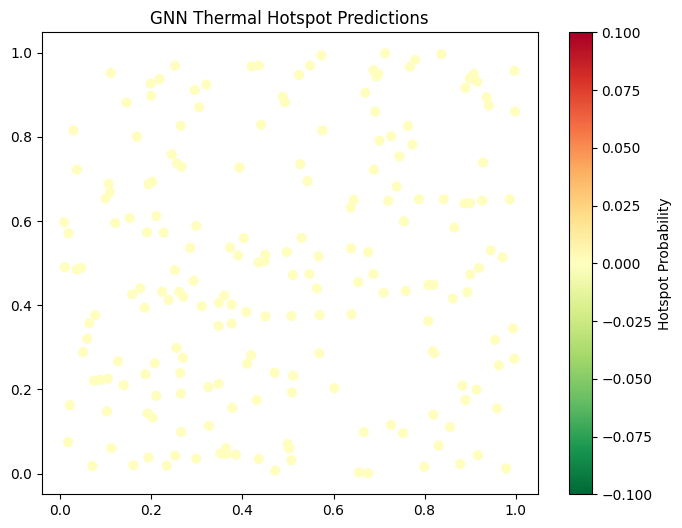

In [14]:
import matplotlib.pyplot as plt

pos = data.x[:, :2].numpy()
preds = (model(data.x, data.edge_index).detach().numpy() > 0.5)

plt.figure(figsize=(8,6))
plt.scatter(pos[:,0], pos[:,1], c=preds, cmap='RdYlGn_r', s=40)
plt.title("GNN Thermal Hotspot Predictions")
plt.colorbar(label="Hotspot Probability")
plt.savefig("thermal_hotspots.png")